<a href="https://colab.research.google.com/github/jayasri1825/Demand-Forecasting-and-Inventory-Optimization/blob/main/Demand_Forecasting_and_Inventory_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [2]:
df = pd.read_csv("demand_inventory.csv")

df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date")

df.head()

,Unnamed: 0,Date,Product_ID,Demand,Inventory
0,0,2023-06-01,P1,51,5500
1,1,2023-06-02,P1,141,5449
2,2,2023-06-03,P1,172,5308
3,3,2023-06-04,P1,91,5136
4,4,2023-06-05,P1,198,5045


In [3]:
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Unnamed: 0  62 non-null     int64         
 1   Date        62 non-null     datetime64[ns]
 2   Product_ID  62 non-null     object        
 3   Demand      62 non-null     int64         
 4   Inventory   62 non-null     int64         
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 2.6+ KB


,Unnamed: 0,Date,Demand,Inventory
count,62.000000,62,62.000000,62.000000
mean,30.500000,2023-07-01 12:00:00,120.709677,2073.822581
min,0.000000,2023-06-01 00:00:00,51.000000,0.000000
25%,15.250000,2023-06-16 06:00:00,85.000000,25.500000
50%,30.500000,2023-07-01 12:00:00,124.000000,1908.000000
75%,45.750000,2023-07-16 18:00:00,152.750000,3594.250000
max,61.000000,2023-08-01 00:00:00,199.000000,5500.000000
std,18.041619,NaN,44.852906,1840.782144


Visualize the demand over time:

In [4]:
fig = px.line(
    df,
    x="Date",
    y="Demand",
    title="Demand Over Time"
)

fig.show()

Visualize the Inventory over time:



In [5]:
fig = px.line(
    df,
    x="Date",
    y="Inventory",
    title="Inventory Over Time"
)

fig.show()

Time-Series Analysis

In [7]:
df = df.set_index("Date")

demand = df["Demand"]

In [8]:
demand_diff = demand.diff().dropna()

ACF & PACF

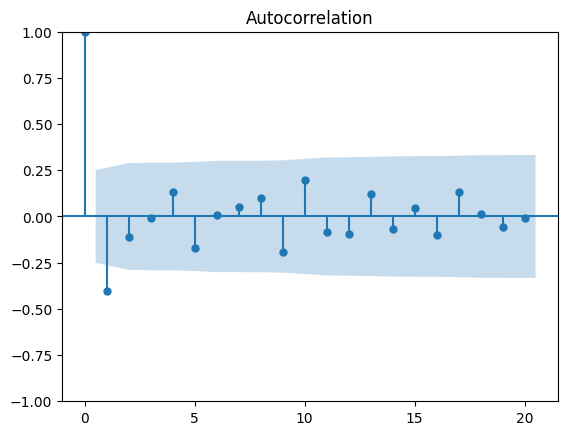

In [9]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots()

plot_acf(demand_diff, ax=ax, lags=20)
plt.show()

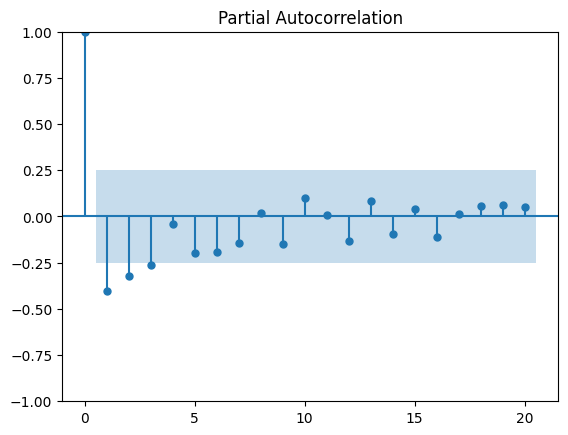

In [10]:
fig, ax = plt.subplots()

plot_pacf(demand_diff, ax=ax, lags=20)
plt.show()

In [11]:
model = SARIMAX(
    demand,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 2)
)

model_fit = model.fit(disp=False)

forecast = model_fit.forecast(steps=10)

print(forecast)

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.



2023-08-02    117.116354
2023-08-03    116.815045
2023-08-04    130.939609
2023-08-05    114.949905
2023-08-06    128.937957
2023-08-07    115.346709
2023-08-08    129.351668
2023-08-09    115.387841
2023-08-10    129.390113
2023-08-11    115.484075
Freq: D, Name: predicted_mean, dtype: float64


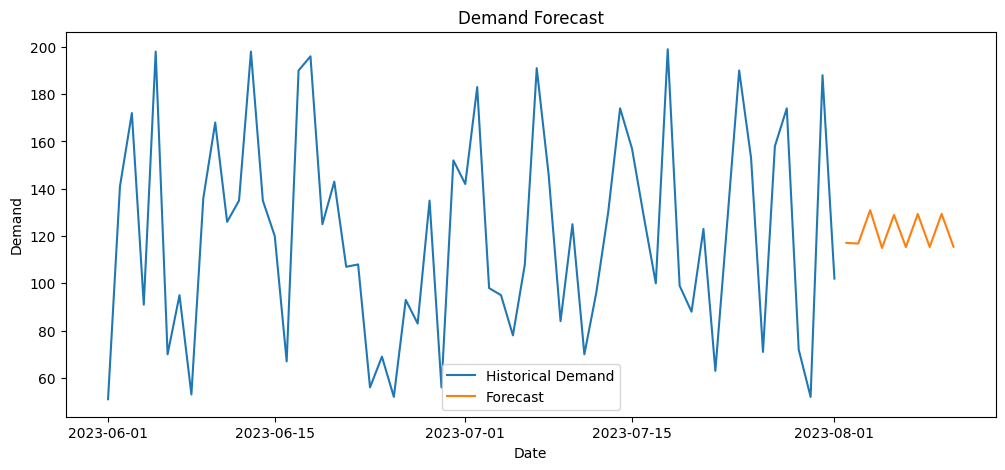

In [12]:
plt.figure(figsize=(12, 5))

plt.plot(demand, label="Historical Demand")
plt.plot(
    forecast.index,
    forecast,
    label="Forecast"
)

plt.xlabel("Date")
plt.ylabel("Demand")
plt.title("Demand Forecast")
plt.legend()
plt.show()

Inventory Optimization

In [13]:
service_level = 0.95

z = 1.645

demand_std = demand_diff.std()

lead_time = 1

safety_stock = z * demand_std * np.sqrt(lead_time)

print("Safety Stock:", safety_stock)

Safety Stock: 101.9011579827435


In [14]:
average_demand = demand.mean()

reorder_point = (
    average_demand * lead_time
    + safety_stock
)

print("Reorder Point:", reorder_point)

Reorder Point: 222.61083540209833


Business Insights

• The forecasting model identifies short-term demand patterns and seasonality.
• Forecasted demand can be used to plan inventory requirements.
• Safety stock provides a buffer against demand uncertainty.
• The reorder point indicates when a replenishment order should be placed.
• Inventory optimization helps balance holding costs and stockout costs.